# Contentsquare Website Analytics

## Project Overview

This project analyses user behaviour and website performance for an e-commerce storefront using data collected through Contentsquare.

The analysis examines overall website engagement, user progression through key website stages, funnel conversion and drop-off, and differences in user behaviour across the available Contentsquare data.

## Objectives

- Analyse overall website engagement and performance
- Examine key performance metrics such as sessions and bounce rate
- Analyse progression through the website funnel
- Identify conversion and drop-off points between key stages
- Examine the journey from the homepage through product listing and product detail pages to the cart
- Analyse available page-view and segment metrics
- Create visualisations to communicate the main findings
- Develop practical UX and business recommendations based on the analysis

## Data Source

The analysis uses data exported from Contentsquare during the project.

The available exports include key performance metrics, funnel data, dashboard metrics and segment-level data. The analysis is based on the metrics and dimensions contained within these exports.

## Analysis Approach

The analysis will:

1. Load and prepare the Contentsquare exports for analysis.
2. Examine overall website performance and engagement.
3. Analyse the user funnel and calculate conversion and drop-off between stages.
4. Examine available page-view and segment metrics.
5. Visualise the main patterns and performance indicators.
6. Interpret the findings and identify potential areas for improvement.
7. Develop UX and business recommendations based on the evidence in the data.

## Key Considerations

The analysis is based on the Contentsquare data available through the project exports. Conclusions are therefore limited to the metrics, stages and segments represented in the available data.

In [1]:
# Import libraries and define the source-data folder
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("data")

In [ ]:
# Data files are stored in the repository's data/ folder.

In [3]:
# Import Contentsquare data from Excel

key_metrics = pd.read_excel(
    DATA_DIR / "key-performance-metrics.xlsx",
    sheet_name="Dashboard",
    header=None
)

dashboard = pd.read_excel(
    DATA_DIR / "funnel-dashboard.xlsx",
    sheet_name="Dashboard",
    header=None
)

segment = pd.read_excel(
    DATA_DIR / "page-view-segment.xlsx",
    sheet_name="Dashboard",
    header=None
)

In [5]:
# Extract key performance metrics

sessions = key_metrics.loc[
    key_metrics[0].eq("Number of sessions"), 1
].iloc[0]

bounce_rate = key_metrics.loc[
    key_metrics[0].eq("Bounce rate"), 1
].iloc[0]

print("Total sessions:", sessions)
print("Bounce rate:", bounce_rate)

Total sessions: 7
Bounce rate: 28.57


In [6]:
# Import funnel data from the Contentsquare Excel export

funnel_data = pd.read_excel(
    DATA_DIR / "funnel-dashboard.xlsx",
    sheet_name="Dashboard",
    header=None
)

# Select the rows containing the funnel steps
funnel = funnel_data[
    funnel_data[0].astype(str).str.startswith("Step ")
].copy()

# Rename the funnel columns
funnel = funnel.iloc[:, :5]
funnel.columns = [
    "Step",
    "Sessions",
    "Conversion Rate",
    "Drop-off Sessions",
    "Drop-off Rate"
]

# Convert numerical columns to numeric values
funnel["Sessions"] = pd.to_numeric(funnel["Sessions"], errors="coerce")
funnel["Conversion Rate"] = pd.to_numeric(funnel["Conversion Rate"], errors="coerce")
funnel["Drop-off Sessions"] = pd.to_numeric(funnel["Drop-off Sessions"], errors="coerce")
funnel["Drop-off Rate"] = pd.to_numeric(funnel["Drop-off Rate"], errors="coerce")

In [7]:
# Analyse session drop-off between funnel stages

funnel["Sessions Lost"] = funnel["Sessions"].shift(1) - funnel["Sessions"]

funnel["Drop-off %"] = (
    funnel["Sessions Lost"] / funnel["Sessions"].shift(1) * 100
)

funnel

,Step,Sessions,Conversion Rate,Drop-off Sessions,Drop-off Rate,Sessions Lost,Drop-off %
13,Step 0 - Homepage,7,100.00,NaN,NaN,NaN,NaN
14,Step 1 - Product Listing Pages,5,71.43,2.0,28.57,2.0,28.571429
15,Step 2 - Product Detail Pages,5,100.00,0.0,0.00,0.0,0.000000
16,Step 3 - Cart,2,40.00,3.0,60.00,3.0,60.000000


In [8]:
# Identify the funnel stage with the highest drop-off rate

largest_drop_off = funnel.loc[funnel["Drop-off %"].idxmax()]

print("Largest drop-off:", largest_drop_off["Step"])
print("Sessions lost:", int(largest_drop_off["Sessions Lost"]))
print("Drop-off rate:", round(largest_drop_off["Drop-off %"], 2), "%")

Largest drop-off: Step 3 - Cart
Sessions lost: 3
Drop-off rate: 60.0 %


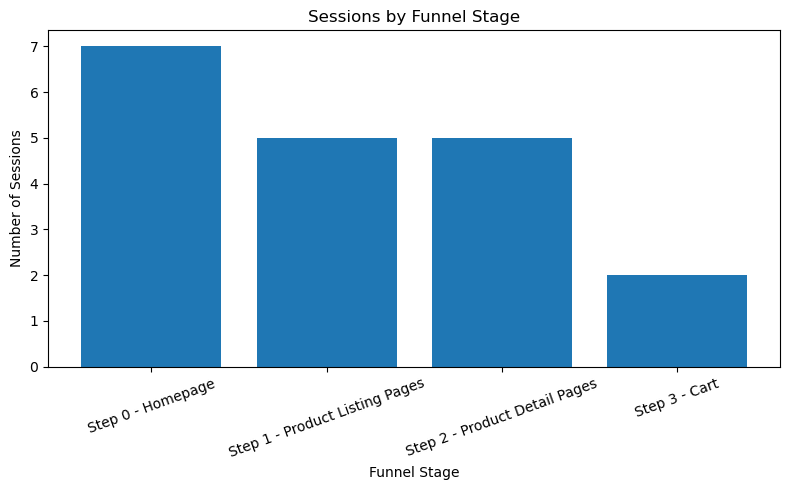

In [9]:
# Visualise sessions at each stage of the funnel

plt.figure(figsize=(8, 5))

plt.bar(funnel["Step"], funnel["Sessions"])

plt.title("Sessions by Funnel Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

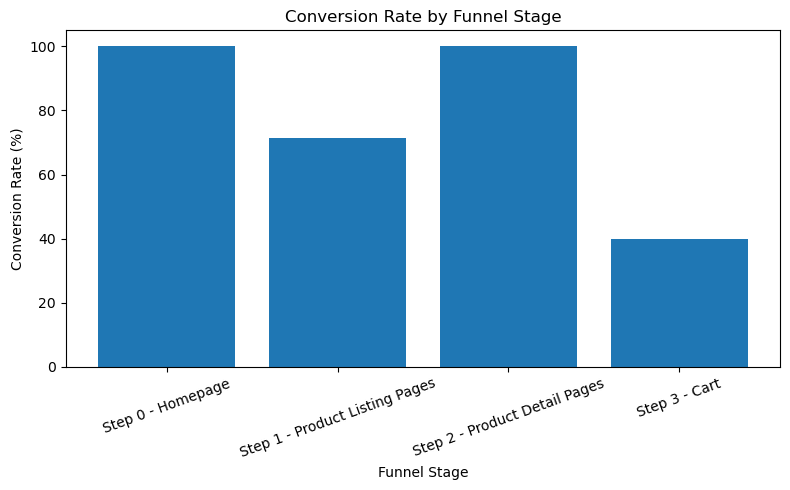

In [10]:
# Visualise conversion rate at each funnel stage

plt.figure(figsize=(8, 5))

plt.bar(funnel["Step"], funnel["Conversion Rate"])

plt.title("Conversion Rate by Funnel Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [11]:
# Calculate overall homepage-to-cart conversion

homepage_sessions = funnel.loc[
    funnel["Step"].eq("Step 0 - Homepage"), "Sessions"
].iloc[0]

cart_sessions = funnel.loc[
    funnel["Step"].eq("Step 3 - Cart"), "Sessions"
].iloc[0]

overall_conversion = (cart_sessions / homepage_sessions) * 100

print("Homepage sessions:", int(homepage_sessions))
print("Cart sessions:", int(cart_sessions))
print("Overall homepage-to-cart conversion:", round(overall_conversion, 2), "%")

Homepage sessions: 7
Cart sessions: 2
Overall homepage-to-cart conversion: 28.57 %


In [13]:
# Import page-view data from the Contentsquare segment export

segment_data = pd.read_excel(
    DATA_DIR / "page-view-segment.xlsx",
    sheet_name="Dashboard",
    header=None
)

# Extract the total number of page views
page_views = segment_data.loc[
    segment_data[0].eq("Number of page views"), 1
].iloc[0]

print("Total page views:", page_views)

Total page views: 120


In [14]:
# Calculate average page views per session

average_page_views = page_views / sessions

print("Average page views per session:", round(average_page_views, 2))

Average page views per session: 17.14


In [18]:
# Create a summary of the key Contentsquare metrics

key_metrics_summary = pd.DataFrame({
    "Metric": [
        "Total sessions",
        "Total page views",
        "Bounce rate",
        "Average page views per session",
        "Homepage-to-cart conversion",
        "Cart drop-off rate"
    ],
    "Value": [
        sessions,
        page_views,
        bounce_rate,
        average_page_views,
        overall_conversion,
        largest_drop_off["Drop-off %"]
    ]
})

key_metrics_summary

,Metric,Value
0,Total sessions,7.000000
1,Total page views,120.000000
2,Bounce rate,28.570000
3,Average page views per session,17.142857
4,Homepage-to-cart conversion,28.571429
5,Cart drop-off rate,60.000000


## Key Findings and Interpretation

### User engagement

The analysis recorded 7 sessions and 120 page views, resulting in an average of 17.14 page views per session. The observed bounce rate was 28.57%.

The relatively high number of page views per session suggests that users who remained engaged interacted with multiple pages during their journeys.

### Funnel performance

The funnel analysis shows that 7 sessions started on the Homepage, 5 progressed to Product Listing Pages, 5 reached Product Detail Pages, and 2 reached the Cart.

The largest observed drop-off occurred at the Cart stage, where 3 sessions were lost. This represents a 60% drop-off from the previous stage and resulted in an overall Homepage-to-Cart conversion rate of 28.57%.

### Business opportunity

The Cart stage represents the clearest area for further investigation. Potential areas to examine include the cart experience, checkout usability, navigation, product information, and any friction that may prevent users from progressing further.

However, the results should be interpreted cautiously because the analysis is based on only 7 sessions. The findings therefore indicate areas for investigation rather than statistically reliable conclusions about the wider customer population.

### Recommended next steps

- Investigate potential friction between the Product Detail and Cart stages.
- Review the cart and checkout experience for usability issues.
- Continue collecting sessions before making stronger conclusions about user behaviour.
- Reassess the funnel as a larger sample of user activity becomes available.